In [ ]:
import requests
import numpy as np
import pandas as pd
from datetime import datetime
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
my_key='722729cfa99e33f0f76a6c4385beb4a6394f1728'

## US Census: Finding variable code (ie B01003_001E for total population)
When you’re trying to web-scrape a Census variable, the safest way is to check the official variables.json metadata file (for example: https://api.census.gov/data/2024/acs/acs1/subject/variables.json) and search for keywords to find the exact variable code.    
It’s also totally fine to start from the Census website table itself: just look at the table name, identify which row and column your data lives in, and then map that position to the corresponding variable code.

## Function to fetch multiple variables from United States Census Bureau

In [ ]:
def fetch_msa_variable_acs1_recent_n_years(var_code: list, var_name: list, api_key: str, n_years: int, max_lookback: int = 10):
    """
    Fetch one ACS1 variable for all MSAs for the most recent n available years.
    """

    current_year = datetime.today().year
    dfs = []
    collected = 0

    for year in range(current_year, current_year - max_lookback, -1):

        if collected >= n_years:
            break

        # determine endpoint
        if var_code.startswith("S"):
            base_url = f"https://api.census.gov/data/{year}/acs/acs1/subject"
        elif var_code.startswith("B"):
            base_url = f"https://api.census.gov/data/{year}/acs/acs1"
        elif var_code.startswith("D"):
            base_url = f"https://api.census.gov/data/{year}/acs/acs1/profile"

        else:
            raise ValueError("Unsupported variable code prefix")

        params = {
            "get": f"NAME,{var_code}",
            "for": "metropolitan statistical area/micropolitan statistical area:*",
            "key": api_key
        }

        response = requests.get(base_url, params=params)

        if response.status_code != 200:
            continue

        data = response.json()

        if len(data) <= 1:
            continue

        df = pd.DataFrame(data[1:], columns=data[0])

        if var_code not in df.columns:
            continue

        df = df.rename(columns={
            var_code: var_name,
            "NAME": "msa_name",
            "metropolitan statistical area/micropolitan statistical area": "msa_code"
        })

        df[var_name] = pd.to_numeric(df[var_name], errors="coerce")
        df["year"] = year

        dfs.append(df[["msa_code", "msa_name", "year", var_name]])
        collected += 1

    if not dfs:
        raise RuntimeError("No available data found")

    return pd.concat(dfs, ignore_index=True)

In [ ]:
# collect useful variables their codes to this dictionary.
variables_acs1 = {"Total_Population": "B01003_001E",
                  "Laborforce_Population": "DP03_0002E",
                  "Employed": "DP03_0004E",
                  "Median_Household_Income": "S1903_C03_001E",
                  "Median_House_Value": "B25077_001E",
                  "Total_Housing_Units": "B25002_001E",
                  "House_Occupied": "B25002_002E",
                  "House_Vacant": "B25002_003E",
                  "Median_Gross_Rent": "B25064_001E",
                  "5_to_9_units": "DP04_0011E",
                  "10_to_19_units":"DP04_0012E",
                  "20_or_more_units":"DP04_0013E"
                 }

In [ ]:
# Model instantiation: Fetch ACS1 variables for all MSAs for the most recent n+1 available years.
# n+1 years of data is needed to construct growh factors, i.e. population growth
dfs = []
for var_name, var_code in variables_acs1.items():
  df = fetch_msa_variable_acs1_recent_n_years(var_code = var_code, var_name = var_name, api_key = my_key, n_years = 5+1)
  dfs.append(df)

In [ ]:
msa_features_recent_5_years = reduce(lambda left, right: pd.merge(
        left, right, on=["msa_code", "msa_name", "year"], how="outer"), dfs)
msa_features_recent_5_years = msa_features_recent_5_years.sort_values(by=['msa_code', 'year'])

msa_features_recent_5_years['Total_Multi_Units']=msa_features_recent_5_years['5_to_9_units']\
+msa_features_recent_5_years['10_to_19_units']+msa_features_recent_5_years['20_or_more_units']

# Filter out MSAs with a total population over 300,000 by the most recent year
population_requirement=300000

most_recent_year = msa_features_recent_5_years['year'].max()
eligible_msa = msa_features_recent_5_years.loc[
    (msa_features_recent_5_years['year'] == most_recent_year) &
    (msa_features_recent_5_years['Total_Population'] >= population_requirement) &
    (msa_features_recent_5_years['msa_name'].str.endswith('Metro Area')),
    'msa_code'].unique()

msa_features_recent_5_years = msa_features_recent_5_years[
    msa_features_recent_5_years['msa_code'].isin(eligible_msa)]

# Print out the number of MSAs achieving population requirement
print(f"By the year {most_recent_year}, {msa_features_recent_5_years['msa_code'].nunique()} \
MSAs have a population of over {population_requirement}.")

By the year 2024, 173 MSAs have a population of over 300000.


In [ ]:
# Note that the U.S. Census Bureau did not release standard 2020 American Community Survey (ACS) 1-year estimates
# because the COVID-19 pandemic severely disrupted data collection, leading to low response rates and high nonresponse bias.
# If it is extremely necessary to use consecutive data including 2020, we shall switch from acs1 to acs5.
msa_features_recent_5_years[msa_features_recent_5_years['msa_code']=='16980']

,msa_code,msa_name,year,Total_Population,Laborforce_Population,Employed,Median_Household_Income,Median_House_Value,Total_Housing_Units,House_Occupied,House_Vacant,Median_Gross_Rent,5_to_9_units,10_to_19_units,20_or_more_units,Total_Multi_Units
512,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2018,9497790,5089589,4792415,70760,247800,3858653,3538101,320552,1110,294938,168767,512310,976015
513,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2019,9457867,5059338,4796817,75379,253800,3869464,3539174,330290,1139,285616,168737,538489,992842
514,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2021,9510390,5063933,4663627,78166,281100,3956161,3670416,285745,1225,282262,176507,556612,1015381
515,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2022,9442159,5097936,4833113,82914,301300,3968906,3726266,242640,1294,304321,180421,572979,1057721
510,16980,"Chicago-Naperville-Elgin, IL-IN Metro Area",2023,9262559,5053959,4791844,87071,316500,3911902,3671659,240243,1390,291526,181012,565152,1037690
511,16980,"Chicago-Naperville-Elgin, IL-IN Metro Area",2024,9406924,5137844,4840603,90770,339700,3924020,3690402,233618,1469,282946,186917,588696,1058559


## Joining US Census data with tax data (Updated)
While US census data are collected on MSA scale, tax data are collected on different scales, using **Gemini**:    
- Residential Effective Rate: State Averaged
- Commercial Effective Rate: proxy of the Largest City of that State

To merge the two datasets in a consistent manner, we assign each MSA the state code corresponding to the state in which its largest principal city (the 1st city in MSA title) is located. We then use this state code to merge the MSA-level Census data with the state-level tax data.

Example:    
(1) **MSA = 'Philadelphia-Camden-Wilmington, PA-NJ-DE-MD Metro Area'**   
----> State Code = 'PA'     
----> Principle city of the state = 'Philadelphia'  
----> MSA US Census data Joined by *Pennsylvania Average Residential Effective Tax Rate* and *Philadelphia Commercial Effective Tax Rate*

(2) **MSA = 'Akron, OH Metro Area'**   
----> State Code = 'OH'   
----> Principle city of the state = 'Columbus'   
----> MSA US Census data Joined by *Ohio Average Residential Effective Tax Rate* and *Columbus Commercial Effective Tax Rate*

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving State Property Tax Comparison_ Hotels vs. Multifamily_New.xlsx to State Property Tax Comparison_ Hotels vs. Multifamily_New.xlsx


In [ ]:
file_name = "State Property Tax Comparison_ Hotels vs. Multifamily_New.xlsx"
df_tax = pd.read_excel(file_name, sheet_name='Tax new')
df_tax['Diff_Effective_Rate']=df_tax['Hotel Effective Rate']-df_tax['Multifamily Effective Rate']
df_tax.head(10)

,State Code,State,MSA (Core County),Hotel Effective Rate,Multifamily Effective Rate,Diff_Effective_Rate
0,AZ,Arizona,Maricopa,0.014450,0.009320,0.00513
1,AL,Alabama,Birmingham,0.014500,0.007250,0.00725
2,AK,Alaska,Anchorage,0.016145,0.016145,0.00000
3,AR,Arkansas,Little Rock,0.014040,0.014040,0.00000
4,CA,California,Los Angeles,0.012500,0.012500,0.00000
5,CO,Colorado,Denver,0.019900,0.005540,0.01436
6,CT,Connecticut,Hartford,0.048300,0.048300,0.00000
7,DE,Delaware,New Castle,0.020300,0.020300,0.00000
8,FL,Florida,Miami-Dade,0.019988,0.019988,0.00000
9,GA,Georgia,Fulton,0.016532,0.016532,0.00000


In [ ]:
# extracting the state code where the largest principal city of the MSA is located
def extract_principal_state(msa_name):
    match =  msa_name.split(', ')[1].split(' ')[0].split('-')[0]
    return match
# extracting the largest principal city of each MSA
def extract_principal_city(msa_name):
    return msa_name.split(',')[0].split('-')[0]

msa_features_recent_5_years['State Code']=msa_features_recent_5_years['msa_name'].apply(extract_principal_state)
msa_features_recent_5_years['Principal_City']=msa_features_recent_5_years['msa_name'].apply(extract_principal_city)

# merging two datasets
msa_features_recent_5_years=pd.merge(msa_features_recent_5_years,
        df_tax[['State', 'State Code', 'Hotel Effective Rate',
       'Multifamily Effective Rate',
       'Diff_Effective_Rate']], on='State Code', how='left')

msa_features_recent_5_years=msa_features_recent_5_years.dropna() # only 1 Puerto Rican MSA is deleted

msa_features_recent_5_years.head()

,msa_code,msa_name,year,Total_Population,Laborforce_Population,Employed,Median_Household_Income,Median_House_Value,Total_Housing_Units,House_Occupied,...,5_to_9_units,10_to_19_units,20_or_more_units,Total_Multi_Units,State Code,Principal_City,State,Hotel Effective Rate,Multifamily Effective Rate,Diff_Effective_Rate
0,10420,"Akron, OH Metro Area",2018,704845,382261,360654,60019,155500,315526,287044,...,12975,13435,21032,47442,OH,Akron,Ohio,0.0406,0.0406,0.0
1,10420,"Akron, OH Metro Area",2019,703479,374176,353676,57158,157200,316217,285647,...,16498,12021,21692,50211,OH,Akron,Ohio,0.0406,0.0406,0.0
2,10420,"Akron, OH Metro Area",2021,700015,362579,343062,63367,181700,317783,292156,...,14485,10987,19882,45354,OH,Akron,Ohio,0.0406,0.0406,0.0
3,10420,"Akron, OH Metro Area",2022,697627,368407,353226,66652,199400,318589,294908,...,13528,11199,23140,47867,OH,Akron,Ohio,0.0406,0.0406,0.0
4,10420,"Akron, OH Metro Area",2023,698398,375374,359014,70125,216000,321142,298193,...,11945,12604,22320,46869,OH,Akron,Ohio,0.0406,0.0406,0.0


## Joining Cap Rate data (data collected using Gemini)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Cap Rate Arbitrage Model Update.xlsx to Cap Rate Arbitrage Model Update.xlsx
Saving State OPEX Assumptions for Housing.xlsx to State OPEX Assumptions for Housing.xlsx


In [ ]:
cap_file = "Cap Rate Arbitrage Model Update.xlsx"
OPEX_file = "State OPEX Assumptions for Housing.xlsx"
df_cap = pd.read_excel(cap_file)
df_OER = pd.read_excel(OPEX_file)
df_cap['Cap Spread'] = df_cap['Hotel Cap Rate'] - df_cap['Apt Cap Rate']
df_OER = df_OER.rename(columns={'Default OPEX %':'OPEX%'})
df_cap.head()

,Rank,State Code,State,Representative MSA,Hotel Cap Rate,Apt Cap Rate,Hotel Value ($),Apartment Value ($),Value Creation ($),Cap Spread
0,1,CA,California,LA / SF Bay Area,0.0775,0.0525,12903226,19047619,6144393,0.0250
1,2,FL,Florida,Miami / Orlando / Tampa,0.0950,0.0600,10526316,16666667,6140351,0.0350
2,2,GA,Georgia,Atlanta,0.0950,0.0600,10526316,16666667,6140351,0.0350
3,4,CO,Colorado,Denver,0.0825,0.0550,12121212,18181818,6060606,0.0275
4,4,UT,Utah,Salt Lake City,0.0825,0.0550,12121212,18181818,6060606,0.0275


In [ ]:
df_OER.head()

,State Code,State,OPEX%,"Primary Cost Drivers (Taxes, Insurance, Climate, Age)"
0,AL,Alabama,0.48,High coastal insurance risk pool; aging plumbi...
1,AK,Alaska,0.46,"Extreme winterization, heating utilities, and ..."
2,AZ,Arizona,0.44,Rising insurance; extreme summer heat accelera...
3,AR,Arkansas,0.45,Moderate taxes; aging housing stock requiring ...
4,CA,California,0.40,Prop 13 caps reassessment risk; extremely high...


In [ ]:
msa_features_recent_5_years.head()

,msa_code,msa_name,year,Total_Population,Laborforce_Population,Employed,Median_Household_Income,Median_House_Value,Total_Housing_Units,House_Occupied,...,5_to_9_units,10_to_19_units,20_or_more_units,Total_Multi_Units,State Code,Principal_City,State,Hotel Effective Rate,Multifamily Effective Rate,Diff_Effective_Rate
0,10420,"Akron, OH Metro Area",2018,704845,382261,360654,60019,155500,315526,287044,...,12975,13435,21032,47442,OH,Akron,Ohio,0.0406,0.0406,0.0
1,10420,"Akron, OH Metro Area",2019,703479,374176,353676,57158,157200,316217,285647,...,16498,12021,21692,50211,OH,Akron,Ohio,0.0406,0.0406,0.0
2,10420,"Akron, OH Metro Area",2021,700015,362579,343062,63367,181700,317783,292156,...,14485,10987,19882,45354,OH,Akron,Ohio,0.0406,0.0406,0.0
3,10420,"Akron, OH Metro Area",2022,697627,368407,353226,66652,199400,318589,294908,...,13528,11199,23140,47867,OH,Akron,Ohio,0.0406,0.0406,0.0
4,10420,"Akron, OH Metro Area",2023,698398,375374,359014,70125,216000,321142,298193,...,11945,12604,22320,46869,OH,Akron,Ohio,0.0406,0.0406,0.0


In [ ]:
msa_features_recent_5_years=pd.merge(msa_features_recent_5_years,
        df_cap[['State Code', 'Hotel Cap Rate', 'Apt Cap Rate', 'Cap Spread']], on='State Code', how='left')

msa_features_recent_5_years=pd.merge(msa_features_recent_5_years,
        df_OER[['State Code', 'OPEX%']], on='State Code', how='left')
msa_features_recent_5_years=msa_features_recent_5_years.dropna()
msa_features_recent_5_years.head()

,msa_code,msa_name,year,Total_Population,Laborforce_Population,Employed,Median_Household_Income,Median_House_Value,Total_Housing_Units,House_Occupied,...,State Code,Principal_City,State,Hotel Effective Rate,Multifamily Effective Rate,Diff_Effective_Rate,Hotel Cap Rate,Apt Cap Rate,Cap Spread,OPEX%
0,10420,"Akron, OH Metro Area",2018,704845,382261,360654,60019,155500,315526,287044,...,OH,Akron,Ohio,0.0406,0.0406,0.0,0.095,0.0675,0.0275,0.49
1,10420,"Akron, OH Metro Area",2019,703479,374176,353676,57158,157200,316217,285647,...,OH,Akron,Ohio,0.0406,0.0406,0.0,0.095,0.0675,0.0275,0.49
2,10420,"Akron, OH Metro Area",2021,700015,362579,343062,63367,181700,317783,292156,...,OH,Akron,Ohio,0.0406,0.0406,0.0,0.095,0.0675,0.0275,0.49
3,10420,"Akron, OH Metro Area",2022,697627,368407,353226,66652,199400,318589,294908,...,OH,Akron,Ohio,0.0406,0.0406,0.0,0.095,0.0675,0.0275,0.49
4,10420,"Akron, OH Metro Area",2023,698398,375374,359014,70125,216000,321142,298193,...,OH,Akron,Ohio,0.0406,0.0406,0.0,0.095,0.0675,0.0275,0.49


In [ ]:
df_2024 = msa_features_recent_5_years[msa_features_recent_5_years['year']==2024]

df_2024=df_2024[['msa_code','msa_name', 'OPEX%']].sort_values('OPEX%', ascending = False)
df_2024.head(50)


,msa_code,msa_name,OPEX%
83,12940,"Baton Rouge, LA Metro Area",0.53
464,29180,"Lafayette, LA Metro Area",0.53
884,43340,"Shreveport-Bossier City, LA Metro Area",0.53
626,35380,"New Orleans-Metairie, LA Metro Area",0.53
223,18880,"Crestview-Fort Walton Beach-Destin, FL Metro Area",0.52
426,27260,"Jacksonville, FL Metro Area",0.52
608,34940,"Naples-Marco Island, FL Metro Area",0.52
554,33100,"Miami-Fort Lauderdale-West Palm Beach, FL Metr...",0.52
470,29460,"Lakeland-Winter Haven, FL Metro Area",0.52
324,23540,"Gainesville, FL Metro Area",0.52


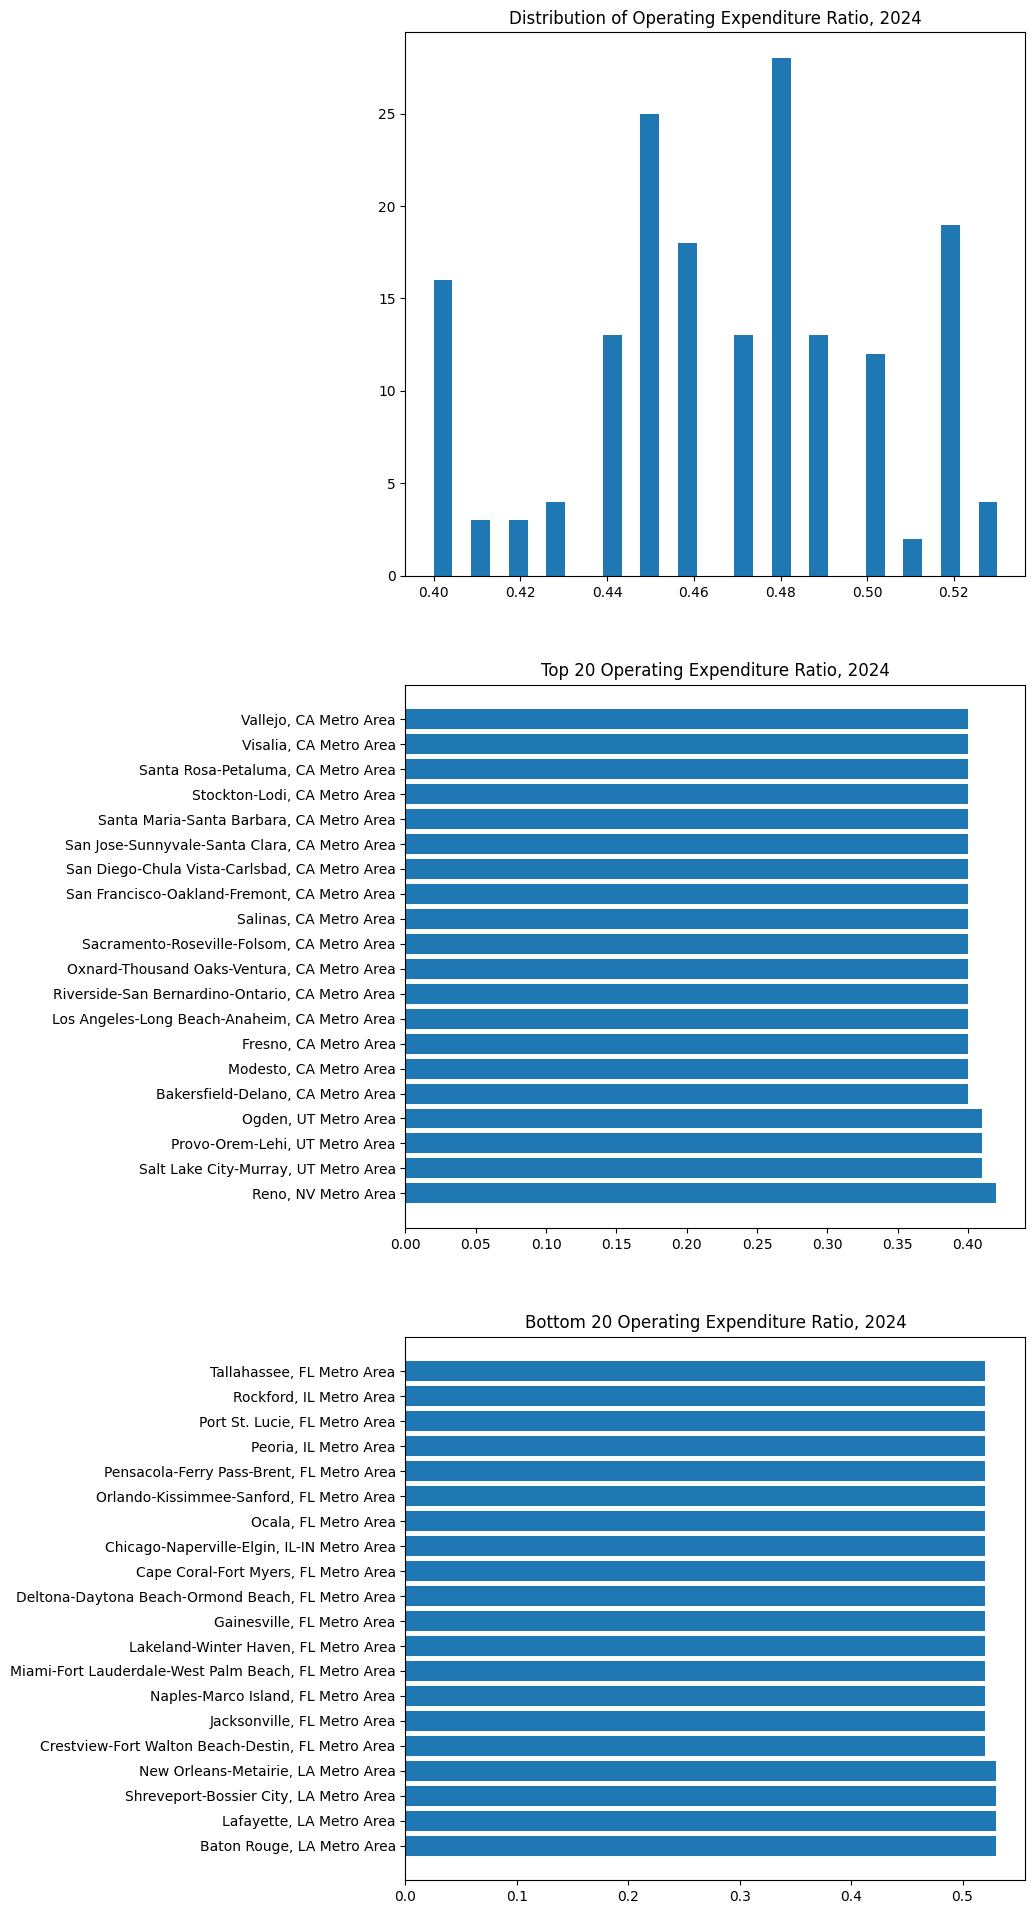

In [ ]:
fig=plt.figure(figsize=(8,24))

ax1=fig.add_subplot(3,1,1)
ax1.hist(df_2024['OPEX%'], bins=30)
ax1.set_title("Distribution of Operating Expenditure Ratio, 2024")

ax2=fig.add_subplot(3,1,2)
ax2.barh(df_2024['msa_name'][-20:], df_2024['OPEX%'][-20:])
ax2.set_title("Top 20 Operating Expenditure Ratio, 2024")

ax3=fig.add_subplot(3,1,3)
ax3.barh(df_2024['msa_name'][:20], df_2024['OPEX%'][:20])
ax3.set_title("Bottom 20 Operating Expenditure Ratio, 2024")



plt.show()

## Joining ESG data (past 5 available years: 2019; 2021-2024)
Data source: RESNET (Residential Energy Services Network)  

Only PDF available. Need to manually convert PDF into Excel    
(free PDF conversion tool: https://www.ilovepdf.com/)


HERS Index: The Home Energy Rating System (HERS) Index is the industry standard by which a home’s energy efficiency is measured. It’s also the nationally recognized system for inspecting and calculating a home’s energy performance.
https://www.hersindex.com/hers-index/understanding-hers-index/

A certified RESNET Home Energy Rater assesses the energy efficiency of a home, assigning it a relative performance score (the HERS® Index Score). **The lower the number, the more energy efficient the home.** A home built to 2006 energy efficiency standards scores 100.

A home with a HERS® Index Score of 70 is 30% more energy efficient than the RESNET Reference Home.
A home with a HERS® Index Score of 130 is 30% less energy efficient than the RESNET Reference Home.*



In [ ]:
uploaded = files.upload()

Saving 2019-HERS-Activity-by-State.xlsx to 2019-HERS-Activity-by-State.xlsx
Saving 2021-HERS-Activity-by-State.xlsx to 2021-HERS-Activity-by-State.xlsx
Saving 2022-HERS-Activity-by-State.xlsx to 2022-HERS-Activity-by-State.xlsx
Saving 2023-HERS-Activity-by-State.xlsx to 2023-HERS-Activity-by-State.xlsx
Saving 2024-HERS-Activity-by-State.xlsx to 2024-HERS-Activity-by-State.xlsx


In [ ]:
years=msa_features_recent_5_years['year'].unique().tolist() #years=[2018, 2019, 2021, 2022, 2023, 2024]
HER_dfs=[]
HER_columns = ['State', 'Number of Homes HERS Rated', 'Average HERS Index Score']
for year in years[1:]: # # the earliest year (2018) is solely for computing demographic growth factors, so we skip it here
  file_name = f"{year}-HERS-Activity-by-State.xlsx"
  df = pd.read_excel(file_name, skiprows=1, usecols=[0,1,2])
  df.columns=HER_columns
  df['year']=year
  HER_dfs.append(df)

HER_dfs=pd.concat(HER_dfs, ignore_index=True)

In [ ]:
msa_features_recent_5_years['State'] = (msa_features_recent_5_years['State'].replace('Washington, D.C.', 'D.C.'))
# Adding Average HERS Index Score to large dataset
msa_features_recent_5_years=pd.merge(msa_features_recent_5_years, HER_dfs[['State', 'year','Average HERS Index Score']],
                                     on=['State', 'year'], how='left')
msa_features_recent_5_years.head()

,msa_code,msa_name,year,Total_Population,Laborforce_Population,Employed,Median_Household_Income,Median_House_Value,Total_Housing_Units,House_Occupied,...,Principal_City,State,Hotel Effective Rate,Multifamily Effective Rate,Diff_Effective_Rate,Hotel Cap Rate,Apt Cap Rate,Cap Spread,OPEX%,Average HERS Index Score
0,10420,"Akron, OH Metro Area",2018,704845,382261,360654,60019,155500,315526,287044,...,Akron,Ohio,0.0406,0.0406,0.0,0.095,0.0675,0.0275,0.49,NaN
1,10420,"Akron, OH Metro Area",2019,703479,374176,353676,57158,157200,316217,285647,...,Akron,Ohio,0.0406,0.0406,0.0,0.095,0.0675,0.0275,0.49,62.0
2,10420,"Akron, OH Metro Area",2021,700015,362579,343062,63367,181700,317783,292156,...,Akron,Ohio,0.0406,0.0406,0.0,0.095,0.0675,0.0275,0.49,61.0
3,10420,"Akron, OH Metro Area",2022,697627,368407,353226,66652,199400,318589,294908,...,Akron,Ohio,0.0406,0.0406,0.0,0.095,0.0675,0.0275,0.49,61.0
4,10420,"Akron, OH Metro Area",2023,698398,375374,359014,70125,216000,321142,298193,...,Akron,Ohio,0.0406,0.0406,0.0,0.095,0.0675,0.0275,0.49,61.0


In [ ]:
msa_features_recent_5_years.columns

Index(['msa_code', 'msa_name', 'year', 'Total_Population',
       'Laborforce_Population', 'Employed', 'Median_Household_Income',
       'Median_House_Value', 'Total_Housing_Units', 'House_Occupied',
       'House_Vacant', 'Median_Gross_Rent', '5_to_9_units', '10_to_19_units',
       '20_or_more_units', 'Total_Multi_Units', 'State Code', 'Principal_City',
       'State', 'Hotel Effective Rate', 'Multifamily Effective Rate',
       'Diff_Effective_Rate', 'Hotel Cap Rate', 'Apt Cap Rate', 'Cap Spread',
       'OPEX%', 'Average HERS Index Score'],
      dtype='object')

# Factor Creation

11 factors are constructed to build 6 indices. ESG factor is currently left aside due to a lack of credibility.
<br><br>
## Economic Index:


*   Employment Rate:

$$Employment~Rate = \frac{Employed}{Laborforce~Population}$$
<br>
*   Employment Growth:

$$Employment~Growth = \frac{Employed_t - Employed_{t-1}}{Employed_{t-1}}$$
<br>

*   Population Growth:

$$Population~Growth = \frac{Total~Pop_t - Total~Pop_{t-1}}{Total~Pop_{t-1}}$$
<br>
*   Income Growth:

$$Income~Growth=\frac{Median~Income_t - Median~Income_{t-1}}{Median ~ Income_{t-1}}$$
<br>

## Housing Stability Index:

*   Rent-to-Income Ratio:

$$Rent~to~Income~Ratio = \frac{Median~Gross~Rent}{Median~Income}$$
<br>

*   Vacanct Rate:


$$Vacancy~Rate = \frac{House~Vacant}{Total~House~Units}$$
<br>


## Supply Pressure Index:


*   New Multi Units:


$$New~Multi~Units = Total~Multi~Units_t - Total~Multi~Units_{t-1}$$


## Pricing Power Index:

*   Rent Growth:

$$Rent~Growth = \frac{Median~Growth~Rent_t - Median~Growth~Rent_{t-1}}{Median~Growth~Rent_{t-1}}$$
<br>


## Valuation Index:
*   Implied Value:

$$Implied~Value = \frac{Annual~Rent*(1-Operating~Expenditure~Ratio)}{Multifamily~Cap~Rate}$$
<br>


## Capital Market Index:

*   Effective Tax Spread:

$$Effective~Tax~Spread = Effective~Tax~Rate_{hotel} - Effective~Tax~Rate_{multifamily} $$     

<br>   

*   Value Creation:


$$Value~Creation = \frac{NOI}{Cap~Rate_{multifamily}} - \frac{NOI}{Cap~Rate_{hotel}}$$
$$ = \$10^6*(\frac{1}{Cap~Rate_{multifamily}} - \frac{1}{Cap~Rate_{hotel}}) $$









In [ ]:
# dropping descriptive columns and renaming tax variables
testing_data = msa_features_recent_5_years.drop(columns=['State Code', 'Principal_City', 'State'])
earliest_year = testing_data['year'].min() #2018

# building new features

# 1. construct Economic factors
testing_data['Employment_Rate'] = testing_data['Employed'] / testing_data['Laborforce_Population']
testing_data['Employment_Growth'] = testing_data.groupby(['msa_code'])['Employed'].pct_change()
testing_data['Pop_Growth'] = testing_data.groupby(['msa_code'])['Total_Population'].pct_change()
testing_data['Income_Growth'] = testing_data.groupby(['msa_code'])['Median_Household_Income'].pct_change()


# 2. construct Housing Affordability factors
testing_data['Rent_to_Income_Ratio'] = testing_data['Median_Gross_Rent'] / testing_data['Median_Household_Income']
testing_data['Vacancy_Rate'] = testing_data['House_Vacant'] / (testing_data['House_Vacant'] + testing_data['House_Occupied'])


# 3. construct Supply Pressure factors
testing_data['New_Multi_Units'] = testing_data.groupby(['msa_code'])['Total_Multi_Units'].diff()


# 4. construct Pricing Power factors
testing_data['Rent_Growth'] = testing_data.groupby(['msa_code'])['Median_Gross_Rent'].pct_change()


# 5. construct valuation factors
testing_data['Implied_Value'] = (testing_data['Median_Gross_Rent']*12*(1-testing_data['OPEX%'])) / testing_data['Apt Cap Rate']

# 6. construct Market factors (already created before)
testing_data['Effective Tax Spread'] = testing_data['Diff_Effective_Rate']
testing_data['Value Creation'] = 1e6*(1/testing_data['Apt Cap Rate'] - 1/testing_data['Hotel Cap Rate'])


# all useful factors (raw & newly constructed) for the sake of investors
# 计划去除Market_Tightness、Value_Potential
factor_list=['Employment_Rate', 'Employment_Growth', 'Pop_Growth', 'Income_Growth',
             'Rent_to_Income_Ratio', 'Vacancy_Rate', 'New_Multi_Units', 'Rent_Growth',
             'Implied_Value', 'Effective Tax Spread', 'Value Creation']

factor_df=testing_data[['msa_code', 'msa_name', 'year'] + factor_list]
factor_df = factor_df[factor_df['year'] > earliest_year]
factor_df.head()

,msa_code,msa_name,year,Employment_Rate,Employment_Growth,Pop_Growth,Income_Growth,Rent_to_Income_Ratio,Vacancy_Rate,New_Multi_Units,Rent_Growth,Implied_Value,Effective Tax Spread,Value Creation
1,10420,"Akron, OH Metro Area",2019,0.945213,-0.019348,-0.001938,-0.047668,0.014521,0.096674,2769.0,0.028501,75253.333333,0.0,4.288499e+06
2,10420,"Akron, OH Metro Area",2021,0.946172,-0.030011,-0.004924,0.108629,0.013588,0.080643,-4857.0,0.037349,78064.000000,0.0,4.288499e+06
3,10420,"Akron, OH Metro Area",2022,0.958793,0.029627,-0.003411,0.051841,0.014223,0.074331,2513.0,0.101045,85952.000000,0.0,4.288499e+06
4,10420,"Akron, OH Metro Area",2023,0.956417,0.016386,0.001105,0.052106,0.014674,0.071461,-998.0,0.085443,93296.000000,0.0,4.288499e+06
5,10420,"Akron, OH Metro Area",2024,0.956900,0.000518,0.005457,0.017668,0.014839,0.057327,518.0,0.029155,96016.000000,0.0,4.288499e+06


In [ ]:
factor_df[factor_df['msa_code']=='29820'].iloc[-1]

,482
msa_code,29820
msa_name,"Las Vegas-Henderson-North Las Vegas, NV Metro ..."
year,2024
Employment_Rate,0.925992
Employment_Growth,0.034297
Pop_Growth,0.026662
Income_Growth,0.066116
Rent_to_Income_Ratio,0.02173
Vacancy_Rate,0.087613
New_Multi_Units,8532.0


In [ ]:
# 15～20% of negative housing unit growth! that is due to occasional MSA rezoning
# to fix the outliers: fill negative values with the median for all MSAs in that year, or simply set negative as zero.
print(f"{100*sum(factor_df['New_Multi_Units']<0)/len(factor_df):.2f}% of New_Multi_Units data are negative")

35.51% of New_Multi_Units data are negative


In [ ]:
factor_df[factor_df['msa_code']=='16980']

,msa_code,msa_name,year,Employment_Rate,Employment_Growth,Pop_Growth,Income_Growth,Rent_to_Income_Ratio,Vacancy_Rate,New_Multi_Units,Rent_Growth,Implied_Value,Effective Tax Spread,Value Creation
163,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2019,0.948112,0.000919,-0.004203,0.065277,0.015110,0.085358,16827.0,0.026126,97194.666667,0.0306,4.558405e+06
164,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2021,0.920950,-0.027766,0.005553,0.036973,0.015672,0.072228,22539.0,0.075505,104533.333333,0.0306,4.558405e+06
165,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2022,0.948053,0.036342,-0.007174,0.060743,0.015607,0.061135,42340.0,0.056327,110421.333333,0.0306,4.558405e+06
166,16980,"Chicago-Naperville-Elgin, IL-IN Metro Area",2023,0.948137,-0.008539,-0.019021,0.050136,0.015964,0.061413,-20031.0,0.074189,118613.333333,0.0306,4.558405e+06
167,16980,"Chicago-Naperville-Elgin, IL-IN Metro Area",2024,0.942147,0.010175,0.015586,0.042483,0.016184,0.059535,20869.0,0.056835,125354.666667,0.0306,4.558405e+06


In [ ]:
factor_df.to_excel("hotelshift_factors_0329.xlsx", index=False)
files.download("hotelshift_factors_0329.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

briefly copying Alec's factor normalization and scoring process, without writing a function

In [ ]:
# 3. Standardization (Scale factors ~ N(0, 1))
factor_df_standardized = factor_df.copy()
factor_df_standardized[factor_list] = (factor_df_standardized.groupby('year')
[factor_list].transform(lambda x: (x - x.mean()) / x.std()))

factor_df_standardized.head()

,msa_code,msa_name,year,Employment_Rate,Employment_Growth,Pop_Growth,Income_Growth,Rent_to_Income_Ratio,Vacancy_Rate,New_Multi_Units,Rent_Growth,Implied_Value,Effective Tax Spread,Value Creation
1,10420,"Akron, OH Metro Area",2019,0.041009,-0.856835,-0.317967,-2.580947,-0.788643,-0.224780,0.072201,-0.202865,-0.813530,-0.399887,-0.493050
2,10420,"Akron, OH Metro Area",2021,0.528069,-0.726254,-1.136720,0.949083,-1.294270,-0.211605,-0.602190,-1.166810,-0.881667,-0.399887,-0.493050
3,10420,"Akron, OH Metro Area",2022,0.416599,-0.355563,-0.855899,-0.474527,-1.116591,-0.305347,-0.267834,0.285332,-0.879850,-0.399887,-0.493050
4,10420,"Akron, OH Metro Area",2023,0.321733,0.119564,-0.009227,0.341440,-1.135782,-0.352361,-0.461830,0.037123,-0.892193,-0.386675,-0.482214
5,10420,"Akron, OH Metro Area",2024,0.468910,-0.764400,-0.955123,-0.839641,-1.110000,-0.632897,-0.258990,-0.710032,-0.953955,-0.386675,-0.482214


In [ ]:
factor_df_standardized.to_excel("hotelshift_factors_standardized_0329.xlsx", index=False)
files.download("hotelshift_factors_standardized_0329.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#MSA Investment Potential Ranking (Latest Year)
##This analysis quantifies the investment worth of each MSA by calculating a composite score based on four key metrics:

###1. Core Factors
*   Population Growth: $$\frac{Total~Pop_t - Total~Pop_{t-1}}{Total~Pop_{t-1}}$$
*   Income Growth: $$\frac{Median~Income_t - Median~Income_{t-1}}{Median ~ Income_{t-1}}$$

*   Market Tightness: $$1 - \frac{House~Vacant}{House~Vacant + House~Occupied}$$
*   Value Potential: $$\frac{1}{Rent\_to\_Income\_Ratio}$$


###2. Output & Interaction
*   Top 10 Rankings: Displayed below for quick identification of top-performing markets.
*   Dynamic Excel Export: Generates an interactive file where you can adjust weights to update scores automatically.

可能可以刪掉 先隱藏起來

In [ ]:
# ==========================================
# WEIGHT CONFIGURATION
# Change these values here; they will flow
# into the scoring logic AND the Excel export.
# ==========================================
INVESTMENT_WEIGHTS = {
    'pop': 0.30,
    'income': 0.30,
    'market': 0.25,
    'value': 0.15
}

def rank_msa_investment_potential(df):
    """
    Ranks MSAs based on investment potential using a weighted scoring model.
    References the global INVESTMENT_WEIGHTS dictionary.
    """
    # Ensure data is sorted by MSA and Year for accurate calculations
    df = df.sort_values(['msa_code', 'year'])

    # 1. Retrieve data for the latest and previous years
    latest_year = df['year'].max()
    prev_year = latest_year - 1

    df_latest = df[df['year'] == latest_year].copy()
    df_prev = df[df['year'] == prev_year].copy()

    # Merge current and previous year data to calculate growth rates
    rank_df = pd.merge(df_latest, df_prev[['msa_code', 'Total_Population', 'Median_Household_Income']],
                       on='msa_code', suffixes=('', '_prev'))

    # 2. Calculate Raw Investment Factors
    rank_df['Pop_Growth'] = (rank_df['Total_Population'] - rank_df['Total_Population_prev']) / rank_df['Total_Population_prev']
    rank_df['Income_Growth'] = (rank_df['Median_Household_Income'] - rank_df['Median_Household_Income_prev']) / rank_df['Median_Household_Income_prev']
    rank_df['Market_Tightness'] = 1 - (rank_df['House_Vacant'] / (rank_df['House_Vacant'] + rank_df['House_Occupied']))
    rank_df['Value_Potential'] = 1 / rank_df['Rent_to_Income_Ratio']

    # 3. Normalization (Scale factors from 0 to 1)
    factors = ['Pop_Growth', 'Income_Growth', 'Market_Tightness', 'Value_Potential']
    for f in factors:
        f_min = rank_df[f].min()
        f_max = rank_df[f].max()
        if f_max != f_min:
            rank_df[f'{f}_norm'] = (rank_df[f] - f_min) / (f_max - f_min)
        else:
            rank_df[f'{f}_norm'] = 0

    # 4. Weighted Scoring using the Global Variable
    rank_df['Investment_Score'] = (
        rank_df['Pop_Growth_norm'] * INVESTMENT_WEIGHTS['pop'] +
        rank_df['Income_Growth_norm'] * INVESTMENT_WEIGHTS['income'] +
        rank_df['Market_Tightness_norm'] * INVESTMENT_WEIGHTS['market'] +
        rank_df['Value_Potential_norm'] * INVESTMENT_WEIGHTS['value']
    ) * 100

    return rank_df.sort_values('Investment_Score', ascending=False)

# Execute the scoring function
results = rank_msa_investment_potential(testing_data)

In [ ]:
ranked_results['year'].unique()

In [ ]:
# 1. Calculate results using the scoring function defined previously
# Ensure the rank_msa_investment_potential code block has been executed
ranked_results = rank_msa_investment_potential(testing_data)

# 2. Extract the Top 10 MSAs
top_10_list = ranked_results.head(10).copy()

# 3. Create a horizontal bar chart
plt.figure(figsize=(12, 8))
# Apply a color gradient where higher scores appear in darker shades of green
sns.barplot(
    data=top_10_list,
    x='Investment_Score',
    y='msa_name',
    palette='Greens_r'
)

# 4. Annotate bars with specific score values at the end of each bar
for index, value in enumerate(top_10_list['Investment_Score']):
    plt.text(value + 1, index, f'{value:.1f}', va='center', fontsize=12, fontweight='bold')

# 5. Enhance chart aesthetics
plt.title(f'Top 10 Investment Potential MSAs ({most_recent_year})', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Total Investment Score (Scale: 0 - 100)', fontsize=14)
plt.ylabel('')
plt.xlim(0, 110)  # Provide extra space for text labels
plt.grid(axis='x', linestyle='--', alpha=0.4)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

# Extra: Print plain text list for quick data copying
print("-" * 50)
print(f"INVESTMENT RANKING TOP 10 ({most_recent_year})")
print("-" * 50)
print(top_10_list[['msa_name', 'Investment_Score']].to_string(index=False))

In [ ]:
!pip install xlsxwriter -q
import ipywidgets as widgets
from IPython.display import display

# 1. Data Preparation
latest_year = testing_data['year'].max()
raw_latest = testing_data[(testing_data['year'] == latest_year) & (testing_data['Total_Population'] >= 300000)].copy()

# Pull normalized factors and scores from the 'results' generated by the previous cell
score_cols = ['msa_code', 'Pop_Growth_norm', 'Income_Growth_norm', 'Market_Tightness_norm', 'Value_Potential_norm', 'Investment_Score']
excel_df = pd.merge(raw_latest, results[score_cols], on='msa_code', how='inner').sort_values(by='Investment_Score', ascending=False)

# Define Main Table Columns
display_cols = ['msa_name', 'msa_code', 'Total_Population', 'Pop_Growth_norm', 'Income_Growth_norm', 'Market_Tightness_norm', 'Value_Potential_norm']
final_table = excel_df[display_cols].copy()
final_table.columns = ['MSA Name', 'MSA Code', 'Population', 'Pop Score', 'Income Score', 'Market Score', 'Value Score']

# 2. Create Dynamic Excel File (Saved to Colab environment)
output_file = f"MSA_Investment_ranking_{latest_year}.xlsx"

with pd.ExcelWriter(output_file, engine='xlsxwriter') as writer:
    final_table.to_excel(writer, index=False, sheet_name='Investment_Analysis')
    workbook, worksheet = writer.book, writer.sheets['Investment_Analysis']

    # Formats
    header_fmt = workbook.add_format({'bold': True, 'bg_color': '#D7E4BC', 'border': 1, 'align': 'center'})
    percent_fmt = workbook.add_format({'num_format': '0%', 'bg_color': '#FFEB9C', 'border': 1, 'bold': True})
    score_fmt = workbook.add_format({'num_format': '0.0', 'bold': True, 'font_color': '#C00000'})

    # 3. Write Weights Controller (Pulling from INVESTMENT_WEIGHTS)
    worksheet.write('L2', 'Dynamic Weight Controller', workbook.add_format({'bold': True, 'font_size': 12}))
    worksheet.write('L3', 'Factor', header_fmt)
    worksheet.write('M3', 'Weight', header_fmt)

    # Mapping global variable keys to readable labels
    ui_mapping = [('Population Growth', 'pop'), ('Income Growth', 'income'),
                  ('Market Tightness', 'market'), ('Value Potential', 'value')]

    for i, (label, key) in enumerate(ui_mapping):
        worksheet.write(i + 3, 11, label)
        worksheet.write(i + 3, 12, INVESTMENT_WEIGHTS[key], percent_fmt)

    # 4. Total Sum Check and Formulas
    worksheet.write(7, 11, 'TOTAL SUM', workbook.add_format({'bold': True, 'top': 2}))
    worksheet.write_formula('M8', '=SUM(M4:M7)', percent_fmt)

    # Final Score column linked to the weight cells (M4:M7)
    worksheet.write(0, 7, 'Final Score', header_fmt)
    for r in range(1, len(final_table) + 1):
        formula = f"=(D{r+1}*$M$4 + E{r+1}*$M$5 + F{r+1}*$M$6 + G{r+1}*$M$7)*100"
        worksheet.write_formula(r, 7, formula, score_fmt)

    # UI Cleanup
    worksheet.set_column('A:A', 35); worksheet.set_column('B:G', 15)
    worksheet.set_column('H:H', 18); worksheet.set_column('L:M', 22)
    worksheet.freeze_panes(1, 0)

# 5. Interactive Download Button Setup
def download_on_click(b):
    files.download(output_file)
    print(f"📥 Download triggered for {output_file}")

download_btn = widgets.Button(
    description='Download Excel File',
    button_style='success', # Green color
    icon='file-excel',
    layout=widgets.Layout(width='250px', height='40px')
)
download_btn.on_click(download_on_click)

print(f"✅ Excel File '{output_file}' generated successfully.")
print("Click the button below to download it to your local machine:")
display(download_btn)

#New Index Scoring test


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# ---------------------------
# Load Data
# ---------------------------
df = pd.read_excel("hotelshift_factors.xlsx")

# Use only the latest year (Investment decision logic)
latest_year = df["year"].max()
df = df[df["year"] == latest_year].copy()

print("Using Year:", latest_year)

# ---------------------------
# 1. Directional Correction (Converting all to "Higher is Better")
# ---------------------------

# Risk variables -> Negated
df["Vacancy_Rate_adj"] = -df["Vacancy_Rate"]
df["Rent_to_Income_adj"] = -df["Rent_to_Income_Ratio"]

# ---------------------------
# 2. Define Six Dimensional Variables
# ---------------------------

# 1. Economic Momentum
economic_vars = [
    "Employment_Growth",
    "Pop_Growth",
    "Income_Growth",
    "Employment_Rate"
]

# 2. Affordability & Stability
stability_vars = [
    "Rent_to_Income_adj",
    "Vacancy_Rate_adj"
]

# 3. Supply Pressure
supply_vars = [
    "Market_Tightness"
]

# 4. Pricing Power
pricing_vars = [
    "Rent_Growth"
]

# 5. Relative Valuation
valuation_vars = [
    "Implied_Value",
    "Value_Potential"
]

# 6. Capital Market / Risk Premium
capital_vars = [
    "Cap Spread",
    "Diff_Effective_Rate"
]

# ---------------------------
# 3. Standardization
# ---------------------------

scaler = StandardScaler()

all_vars = (
    economic_vars +
    stability_vars +
    supply_vars +
    pricing_vars +
    valuation_vars +
    capital_vars
)

df_scaled = df.copy()
df_scaled[all_vars] = scaler.fit_transform(df_scaled[all_vars])

# ---------------------------
# 4. Create Sub-Indices
# ---------------------------

df_scaled["Economic_Index"] = df_scaled[economic_vars].mean(axis=1)
df_scaled["Stability_Index"] = df_scaled[stability_vars].mean(axis=1)
df_scaled["Supply_Index"] = df_scaled[supply_vars].mean(axis=1)
df_scaled["Pricing_Index"] = df_scaled[pricing_vars].mean(axis=1)
df_scaled["Valuation_Index"] = df_scaled[valuation_vars].mean(axis=1)
df_scaled["Capital_Index"] = df_scaled[capital_vars].mean(axis=1)

# ---------------------------
# 5. Weighted Total Score
# (You can explain the weighting logic in your report)
# ---------------------------

df_scaled["Index_Score"] = (
    0.25 * df_scaled["Economic_Index"] +
    0.15 * df_scaled["Stability_Index"] +
    0.15 * df_scaled["Supply_Index"] +
    0.15 * df_scaled["Pricing_Index"] +
    0.20 * df_scaled["Valuation_Index"] +
    0.10 * df_scaled["Capital_Index"]
)

# ---------------------------
# 6. Ranking
# ---------------------------

ranking = df_scaled.sort_values("Index_Score", ascending=False)

print("\nTop 10 Markets:")
print(
    ranking[["msa_code", "msa_name", "Index_Score"]]
    .head(10)
    .reset_index(drop=True)
)

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_scaled["Index_Score"], kde=True)

plt.title("Distribution of Market Attractiveness Index")
plt.xlabel("Index Score")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# top 10
top10 = ranking.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Index_Score",
    y="msa_name"
)

plt.title("Top 10 Market Attractiveness Index", fontsize=16)
plt.xlabel("Index Score (Standardized)")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

#top 3
top3 = ranking.head(3)

categories = [
    "Economic_Index",
    "Stability_Index",
    "Supply_Index",
    "Pricing_Index",
    "Valuation_Index",
    "Capital_Index"
]

N = len(categories)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

for i in range(3):
    values = top3.iloc[i][categories].tolist()
    values += values[:1]
    ax.plot(angles, values, label=top3.iloc[i]["msa_name"])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

plt.title("Top 3 Markets - 6 Dimension Comparison", size=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

In [ ]:
# ================================
# Single MSA Radar Chart (by msa_code)
# ================================

import numpy as np
import matplotlib.pyplot as plt

# 🔹 Change this to the msa_code you want to visualize
target_code = 24540

# Six dimensions (consistent with the previous indexing)
categories = [
    "Economic_Index",
    "Stability_Index",
    "Supply_Index",
    "Pricing_Index",
    "Valuation_Index",
    "Capital_Index"
]

# Extract data for the specific market
msa_data = df_scaled[df_scaled["msa_code"] == target_code]

if msa_data.empty:
    print("msa_code not found, please check if it exists.")
else:
    msa_name = msa_data.iloc[0]["msa_name"]
    values = msa_data.iloc[0][categories].tolist()

    # Radar chart setup
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

    # Complete the loop for the radar chart
    angles += angles[:1]
    values += values[:1]

    plt.figure(figsize=(8,8))
    ax = plt.subplot(111, polar=True)

    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.2)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)

    plt.title(f"{msa_name} - 6 Dimension Profile", size=14)
    plt.show()